## What is Agentic RAG with LangGraph

In a traditional RAG system you typically have:

query → retrieve documents → generate answer.
    
Agentic RAG takes this further: the system becomes more agentic (i.e., decision-making, loops, conditional logic) and the orchestration is managed via LangGraph.
Key features:
    
- The system decides whether to retrieve (or reuse context) or generate immediately. 

- It may evaluate retrieved docs (grade & filter) and, if insufficient, may rewrite the query and retry retrieval. 

- The workflow is expressed as a graph (nodes = steps/tools, edges = transitions/conditions) so you can loop, branch, do multiple tool calls. 

- LangGraph supports state, persistence, and complex orchestration beyond simple chains.

In [1]:
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph
from typing import TypedDict, List
from langgraph.constants import START,END

In [2]:
class AgentState(TypedDict):
    messages: List
    query: str
    retrieved_docs: list
    retry_count: int


In [4]:
# 1. Sentence Transformer embeddings
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# 2. Create FAISS vector store
texts = [
    "LangGraph is a framework for building agentic workflows.",
    "FAISS is a library for efficient similarity search and clustering of dense vectors.",
    "ChatGroq provides ultra-fast LLM inference using Groq hardware.",
    "RAG stands for Retrieval-Augmented Generation."
]

# Build FAISS index
vectorstore = FAISS.from_texts(texts, embedding=embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# 3. Initialize ChatGroq (replace with your API key)

groq_api="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"

llm = ChatGroq(
    groq_api_key=groq_api,  # Replace with your actual key
    model_name="llama-3.3-70b-versatile"
)

C:\Users\omkar\AppData\Local\Temp\ipykernel_31632\2666178784.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
E:\Anaconda\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


| Node                           | Must Return     | Notes                             |
| ------------------------------ | --------------- | --------------------------------- |
| `generate_query_or_respond_fn` | dict-like state | sets up query                     |
| `retrieve_documents_fn`        | dict-like state | adds retrieved docs               |
| `grade_documents_fn`           | dict-like state | **no routing here**               |
| `route_from_grader()`          | str             | **returns node name** for routing |
| `rewrite_query_fn`             | dict-like state | modifies query                    |
| `generate_answer_fn`           | dict-like state | appends answer                    |


**generate_query_or_respond_fn**

- It inspects state["messages"][-1].content (i.e., the user’s last message).

- It checks if the message contains keywords like ["what", "who", "when", "where", "how", "explain", "rag", "langgraph"]. If none of those keywords are present, it decides we don’t need retrieval.

- If no retrieval is needed, it invokes the LLM (llm.invoke(...)) to produce a direct answer, appends this answer to state["messages"], and leaves the query field alone.

- If retrieval is needed, it sets state["query"] = user_message, so that downstream nodes know what to search for.

**retrieve_documents_fn**

- Reads query = state["query"].

- Calls retriever.get_relevant_documents(query).

- Stores the returned list of document objects in state["retrieved_docs"].

- Returns the updated state.

This node’s purpose is to prepare the state for a routing decision about whether the retrieved documents are sufficient for answering the query, or whether we need to retry search (by rewriting the query)

In [6]:
def generate_query_or_respond_fn(state: AgentState):
    user_message = state["messages"][-1].content
    needs_retrieval = any(
        word in user_message.lower() for word in 
        ["what", "who", "when", "where", "how", "explain", "rag", "langgraph"]
    )
    
    if not needs_retrieval:
        response = llm.invoke([HumanMessage(content=user_message)])
        state["messages"].append(AIMessage(content=response.content))
    else:
        state["query"] = user_message
    return state

def retrieve_documents_fn(state: AgentState):
    query = state["query"]
    docs = retriever.get_relevant_documents(query)
    state["retrieved_docs"] = docs
    return state

def grade_documents_fn(state: AgentState):
    # Node updates state only; routing handled by route_from_grader
    return state

def rewrite_query_fn(state: AgentState):
    query = state["query"]
    prompt = f"Rewrite this query to get better search results: {query}"
    new_query = llm.invoke([HumanMessage(content=prompt)]).content.strip()
    state["query"] = new_query
    state["retry_count"] += 1
    return state

def generate_answer_fn(state: AgentState):
    query = state["query"]
    docs = state["retrieved_docs"]
    context = "\n\n".join(d.page_content for d in docs)
    
    prompt = f"""Answer the question using the context below.
            \n\nContext:\n{context}\n\nQuestion: {query}"""
    answer = llm.invoke([HumanMessage(content=prompt)])
    state["messages"].append(AIMessage(content=answer.content))
    return state


In [7]:
def route_from_grader(state: AgentState) -> str:
    docs = state["retrieved_docs"]
    query = state["query"]
    grading_prompt = f"""Query: {query}\nDocs:\n{[d.page_content for d in docs]}
                    \n\nAre these docs sufficient? yes or no."""
    result = llm.invoke([HumanMessage(content=grading_prompt)])
    
    if "yes" in result.content.lower():
        return "generate_answer"
    else:
        return "rewrite_query"


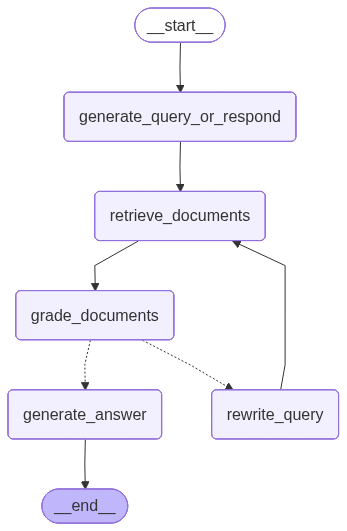

In [8]:
graph_builder = StateGraph(AgentState)

# --- Add nodes ---
graph_builder.add_node("generate_query_or_respond", generate_query_or_respond_fn)
graph_builder.add_node("retrieve_documents", retrieve_documents_fn)
graph_builder.add_node("grade_documents", grade_documents_fn)
graph_builder.add_node("rewrite_query", rewrite_query_fn)
graph_builder.add_node("generate_answer", generate_answer_fn)

# --- Add edges ---
graph_builder.add_edge(START, "generate_query_or_respond")
graph_builder.add_edge("generate_query_or_respond", "retrieve_documents")
graph_builder.add_edge("retrieve_documents", "grade_documents")

graph_builder.add_conditional_edges(
    "grade_documents",
    route_from_grader,
    {
        "generate_answer": "generate_answer",
        "rewrite_query": "rewrite_query"
    }
)

graph_builder.add_edge("rewrite_query", "retrieve_documents")
graph_builder.add_edge("generate_answer", END)

# --- Compile graph ---
graph = graph_builder.compile()
graph

In [9]:
initial_state = {
    "messages": [HumanMessage(content="What is FAISS and how is it used in RAG?")],
    "query": "",
    "retrieved_docs": [],
    "retry_count": 0
}

result = graph.invoke(initial_state)
print("\n🤖 Final Answer:\n", result["messages"][-1].content)


C:\Users\omkar\AppData\Local\Temp\ipykernel_31632\786729764.py:17: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents(query)
E:\Anaconda\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
E:\Anaconda\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
E:\Anaconda\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
E:\Anaconda\Lib

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT